# 01 — Project Setup and Overview
This notebook trains a **1‑step LSTM** forecaster on monthly NEDCo data, then rolls it forward to predict **kWh, GHC, and paymoney** for future months.


## 02 — Project Setup and Config

In [8]:
# === Project Setup and Config (relative paths) ===
DB_PATH = "../data/warehouse.duckdb"
TABLE = "prod.sales"
REQUIRED_COLS = ["meterid","chargedate","loc","res","kwh","ghc","paymoney"]
ARTIFACT_DIR = "../models"

MODEL_PATH = f"{ARTIFACT_DIR}/lstm_next.keras"
SCALER_PATH = f"{ARTIFACT_DIR}/scaler.pkl"
Y_SCALER_PATH = f"{ARTIFACT_DIR}/scaler_y.pkl"   # optional, for separate y-scaler
FEATURES_PATH = f"{ARTIFACT_DIR}/feature_cols.json"

HORIZON = 12
SEQ_LEN = 12
TARGETS = ["kwh", "ghc", "paymoney"]
BATCH_SIZE = 256
EPOCHS = 50
VAL_SPLIT_FRAC = 0.2
MAX_TRAIN_DATE = "2020-09-30"


## 03 — Imports

In [2]:

import os, json, math
import numpy as np
import pandas as pd
import duckdb, joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("TensorFlow:", tf.__version__)


TensorFlow: 2.17.1


## 04 — Load Data from DuckDB

In [3]:
DB_PATH

'../data/warehouse.duckdb'

In [4]:

con = duckdb.connect(DB_PATH)
print("Tables:", con.execute("SHOW TABLES").fetchall())
df = con.execute(f"SELECT * FROM {TABLE}").fetchdf()
print(df.shape, df.dtypes.head())
missing = sorted(set(REQUIRED_COLS) - set(df.columns))
if missing: raise ValueError(f"Missing required columns: {missing}")


Tables: []
(2867046, 11) chargedate        datetime64[us]
meterid                    int64
chargedate_str            object
loc                       object
res                       object
dtype: object


## 05 — Data Cleaning

In [5]:

df = df.copy()
df["chargedate"] = pd.to_datetime(df["chargedate"])
df = df.drop_duplicates(subset=["meterid","chargedate"]).sort_values(["meterid","chargedate"])
for c in ["kwh","ghc","paymoney"]:
    df = df[df[c].notna()]; df = df[df[c] >= 0]
if MAX_TRAIN_DATE is not None:
    df = df[df["chargedate"] <= pd.to_datetime(MAX_TRAIN_DATE)]
print("After cleaning:", df.shape)


After cleaning: (2704057, 11)


## 06 — Feature Engineering

In [4]:
# --- Feature Engineering: time, lags, rolling stats (no leakage) ---
def add_features(df):
    df = df.sort_values(["meterid","chargedate"]).copy()

    # time features
    df["month_num"]  = df["chargedate"].dt.month
    df["year"]       = df["chargedate"].dt.year
    df["month_sin"]  = np.sin(2*np.pi*df["month_num"]/12)
    df["month_cos"]  = np.cos(2*np.pi*df["month_num"]/12)
    df["weekday"]    = df["chargedate"].dt.weekday
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)
    # optional season flag
    df["season"] = pd.cut(df["month_num"], [0,3,6,9,12], labels=[0,1,2,3]).astype(int)

    # categorical encodings
    df["loc_enc"] = df["loc"].astype("category").cat.codes
    df["res_enc"] = df["res"].astype("category").cat.codes

    # per-meter past-only signals
    def per_meter(g):
        g = g.copy()
        # lags
        for c in ["kwh","ghc","paymoney"]:
            g[f"{c}_lag1"] = g[c].shift(1)
            g[f"{c}_lag2"] = g[c].shift(2)
            g[f"{c}_lag3"] = g[c].shift(3)
            # rolling means on prior values
            g[f"{c}_ma3"]  = g[c].shift(1).rolling(3, min_periods=3).mean()
            g[f"{c}_ma6"]  = g[c].shift(1).rolling(6, min_periods=6).mean()
            g[f"{c}_ma12"] = g[c].shift(1).rolling(12, min_periods=12).mean()
            # momentum
            g[f"{c}_diff1"] = g[c].diff(1)          # uses t - t-1
            g[f"{c}_pc1"]   = g[c].pct_change(1)    # (t - t-1)/t-1
        return g

    df = df.groupby("meterid", group_keys=False).apply(per_meter)

    # drop rows that lack required history for windows
    min_hist = 12  # because we use up to ma12
    df = df.groupby("meterid", group_keys=False).apply(lambda g: g.iloc[min_hist:]).reset_index(drop=True)
    return df

df_feat = add_features(df)

# choose features
feature_cols = [
    "month_num","year","month_sin","month_cos","weekday","is_weekend","season",
    "loc_enc","res_enc",
    # core targets as inputs too
    "kwh","ghc","paymoney",
    # kwh signals
    "kwh_lag1","kwh_lag2","kwh_lag3","kwh_ma3","kwh_ma6","kwh_ma12","kwh_diff1","kwh_pc1",
    # ghc signals
    "ghc_lag1","ghc_lag2","ghc_lag3","ghc_ma3","ghc_ma6","ghc_ma12","ghc_diff1","ghc_pc1",
    # paymoney signals
    "paymoney_lag1","paymoney_lag2","paymoney_lag3","paymoney_ma3","paymoney_ma6","paymoney_ma12",
    "paymoney_diff1","paymoney_pc1",
]
print(len(feature_cols), "features")


In [7]:
df_feat[feature_cols].shape

(1918840, 36)

## 07 — Sequence Builder

In [5]:
def build_sequences_with_dates(frame: pd.DataFrame,
                               seq_len: int,
                               horizon: int,
                               feature_cols,
                               target_cols):
    X_list, y_list, d_list = [], [], []
    for _, g in frame.groupby("meterid"):
        g = g.sort_values("chargedate")
        F = g[feature_cols].to_numpy(dtype=float)
        T = g[target_cols].to_numpy(dtype=float)
        dates = g["chargedate"].to_numpy()

        if len(g) <= seq_len + horizon - 1:
            continue

        for i in range(seq_len, len(g) - horizon + 1):
            X_list.append(F[i-seq_len:i, :])
            y_list.append(T[i:i+horizon, :])       # collect full 12-step block
            d_list.append(dates[i+horizon-1])      # date of last target step

    if not X_list:
        raise ValueError("No sequences built. Check data, SEQ_LEN, and HORIZON.")

    import numpy as np
    X = np.stack(X_list, axis=0)
    y = np.stack(y_list, axis=0)                   # now shape (N, 12, 3)
    d = np.array(d_list)
    order = np.argsort(d)
    return X[order], y[order], d[order]

# Build and split
HORIZON = 12
X_all, y_all, d_all = build_sequences_with_dates(df_feat, SEQ_LEN, HORIZON, feature_cols, TARGETS)
cut = int(len(X_all) * (1 - VAL_SPLIT_FRAC))
X_tr, y_tr = X_all[:cut], y_all[:cut]
X_va, y_va = X_all[cut:], y_all[cut:]
print("Train:", X_tr.shape, "Val:", X_va.shape)


## 08 — Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

# --- X scaling (fit on train only) ---
n_feat = X_tr.shape[2]
sx = StandardScaler()
X_tr_2d = X_tr.reshape(-1, n_feat)
X_va_2d = X_va.reshape(-1, n_feat)
sx.fit(X_tr_2d)
Xs_tr = sx.transform(X_tr_2d).reshape(X_tr.shape)
Xs_va = sx.transform(X_va_2d).reshape(X_va.shape)

# --- y scaling (multi-step target: [N, HORIZON, n_targets]) ---
n_targ = y_tr.shape[2]
sy = StandardScaler()
y_tr_2d = y_tr.reshape(-1, n_targ)
y_va_2d = y_va.reshape(-1, n_targ)
sy.fit(y_tr_2d)
ys_tr = sy.transform(y_tr_2d).reshape(y_tr.shape)
ys_va = sy.transform(y_va_2d).reshape(y_va.shape)

Xs_tr.shape, Xs_va.shape, ys_tr.shape, ys_va.shape


((670585, 12, 36), (167647, 12, 36), (670585, 12, 3), (167647, 12, 3))

## 09 — LSTM Model Definition

In [11]:
# === Loss + metrics + model: stacked BiLSTM, Conv1D front-end, decoder attention, LN, higher dropout ===
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# ---- horizon weights (nearer horizons matter more) ----
def horizon_weights(H, decay=0.15):
    w = tf.exp(-decay * tf.cast(tf.range(H), tf.float32))
    return w / tf.reduce_sum(w)

# ---- per-target weights (emphasize kWh) ----
# expects TARGETS like ["kwh","ghc","paymoney"]
_target_w_map = {"kwh": 2.0, "ghc": 1.0, "paymoney": 1.0}
def target_weights(target_names):
    return tf.constant([_target_w_map.get(t, 1.0) for t in target_names], dtype=tf.float32)

# ---- weighted Huber with horizon + target weights ----
def make_weighted_huber(target_names, delta=1.0, decay=0.15):
    tw = target_weights(target_names)                  # shape (T,)
    def loss(y_true, y_pred):
        H = tf.shape(y_true)[1]
        hw = horizon_weights(H, decay)                # shape (H,)
        err = tf.abs(y_true - y_pred)                 # (B,H,T)
        hub = tf.where(err < delta, 0.5*tf.square(err), delta*(err - 0.5*delta))
        # apply weights: broadcast (H,) and (T,)
        w_h = hw[tf.newaxis, :, tf.newaxis]
        w_t = tw[tf.newaxis, tf.newaxis, :]
        return tf.reduce_sum(hub * w_h * w_t)
    loss.__name__ = "weighted_huber_ht"
    return loss

# ---- horizon-weighted metrics (plus H1 MAE) ----
def weighted_rmse(decay=0.15):
    def fn(y_true, y_pred):
        H = tf.shape(y_true)[1]; hw = horizon_weights(H, decay)[tf.newaxis, :, tf.newaxis]
        se = tf.square(y_pred - y_true)
        return tf.sqrt(tf.reduce_sum(se * hw))
    fn.__name__ = f"wRMSE_d{str(decay).replace('.','p')}"
    return fn

def weighted_smape(decay=0.15, eps=1e-6):
    def fn(y_true, y_pred):
        H = tf.shape(y_true)[1]; hw = horizon_weights(H, decay)[tf.newaxis, :, tf.newaxis]
        num = tf.abs(y_pred - y_true)
        den = tf.abs(y_true) + tf.abs(y_pred) + eps
        return 200.0 * tf.reduce_sum((num/den) * hw)
    fn.__name__ = f"wSMAPE_d{str(decay).replace('.','p')}"
    return fn

def mae_h1(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true[:, 0, :] - y_pred[:, 0, :]))

# ---- Attention block (Luong-style using keras.layers.Attention) ----
def add_attention(dec_seq, enc_seq):
    ctx = layers.Attention(use_scale=True)([dec_seq, enc_seq])   # (B,H,D) from values=enc_seq
    return layers.Concatenate()([dec_seq, ctx])

# ---- Model with Conv1D + stacked (Bi)LSTM encoder, decoder LSTM, attention, LayerNorm, dropout=0.3 ----
def build_model(seq_len: int, n_feat: int, n_targets: int, horizon: int, target_names):
    inp = keras.Input(shape=(seq_len, n_feat))

    # Conv1D front-end for local patterns (causal to avoid leakage)
    x = layers.Conv1D(filters=64, kernel_size=3, padding="causal", activation="relu")(inp)
    x = layers.Dropout(0.1)(x)

    # Stacked encoder
    e1 = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3))(x)
    e1 = layers.LayerNormalization()(e1)
    e2 = layers.LSTM(64, return_sequences=True, dropout=0.3)(e1)     # keep sequences for attention
    e2 = layers.LayerNormalization()(e2)

    # Compress encoder sequence to a state vector
    enc_last = layers.LSTM(64, return_sequences=False, dropout=0.3)(e2)
    enc_last = layers.LayerNormalization()(enc_last)

    # Decoder
    d = layers.RepeatVector(horizon)(enc_last)
    d = layers.LSTM(64, return_sequences=True, dropout=0.3)(d)
    d = layers.LayerNormalization()(d)

    # Attention over encoder sequence
    d = add_attention(d, e2)

    # Output heads
    out = layers.TimeDistributed(layers.Dense(n_targets))(d)  # (B,H,T)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),   # lower LR for fine-tuning
        loss=make_weighted_huber(target_names, delta=1.0, decay=0.15),
        metrics=[weighted_rmse(0.15), weighted_smape(0.15), mae_h1, "mae"],
    )
    return model

In [10]:
# build
model = build_model(SEQ_LEN, n_feat, len(TARGETS), HORIZON, TARGETS)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 12, 36)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 12, 64)            │           6,976 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 12, 64)            │               0 │ conv1d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 12, 256)           │         197,632 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 12, 256)           │             512 │ bidirectional[0][0]        │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 12, 64)            │          82,176 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 12, 64)            │             128 │ lstm_1[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 64)                │          33,024 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 64)                │             128 │ lstm_2[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ repeat_vector (RepeatVector)  │ (None, 12, 64)            │               0 │ layer_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_3 (LSTM)                 │ (None, 12, 64)            │          33,024 │ repeat_vector[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_3         │ (None, 12, 64)            │             128 │ lstm_3[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention (Attention)         │ (None, 12, 64)            │               1 │ layer_normalization_3[0][… │
│                               │                           │                 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 12, 128)           │               0 │ layer_normalization_3[0][… │
│                               │                           │                 │ attention[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 354,116 (1.35 MB)

 Trainable params: 354,116 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

## 10 — Training and Callbacks

In [20]:
# === Training tweaks: larger batch, stricter plateau, early stopping on H1 ===
from pathlib import Path
from tensorflow import keras

PRIMARY_MONITOR = "val_mae_h1"  # prioritize near horizon
Path(ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)
ckpt_path = f"{ARTIFACT_DIR}/lstm_12step.attn_conv.best.keras"

BATCH_SIZE = 512  # smoother gradients
callbacks = [
    keras.callbacks.EarlyStopping(monitor=PRIMARY_MONITOR, mode="min", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor=PRIMARY_MONITOR, mode="min", factor=0.5, patience=3, min_lr=5e-6),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor=PRIMARY_MONITOR, mode="min", save_best_only=True),
    keras.callbacks.TerminateOnNaN(),
]

history = model.fit(
    Xs_tr, ys_tr,
    validation_data=(Xs_va, ys_va),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    verbose=1,
    callbacks=callbacks,
)


Epoch 1/50
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 338s 247ms/step - loss: 274.8538 - mae: 0.3522 - mae_h1: 0.3314 - w_rmse_d0p15: 27.4914 - w_smape_d0p15: 143759.2969 - val_loss: 181.7829 - val_mae: 0.2824 - val_mae_h1: 0.2172 - val_w_rmse_d0p15: 22.2502 - val_w_smape_d0p15: 118614.3281 - learning_rate: 1.0000e-04
Epoch 2/50
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 304s 232ms/step - loss: 181.1210 - mae: 0.2703 - mae_h1: 0.2358 - w_rmse_d0p15: 21.9034 - w_smape_d0p15: 123227.4844 - val_loss: 174.8203 - val_mae: 0.2748 - val_mae_h1: 0.2059 - val_w_rmse_d0p15: 21.3423 - val_w_smape_d0p15: 116024.8047 - learning_rate: 1.0000e-04
Epoch 3/50
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 304s 232ms/step - loss: 171.3648 - mae: 0.2604 - mae_h1: 0.2215 - w_rmse_d0p15: 20.7914 - w_smape_d0p15: 119501.7266 - val_loss: 173.0448 - val_mae: 0.2726 - val_mae_h1: 0.2023 - val_w_rmse_d0p15: 21.0869 - val_w_smape_d0p15: 115108.2812 - learning_rate: 1.0000e-04
Epoch 4/50
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 305s 233ms/step - loss: 166.2873 -

## 11 — Evaluation

In [21]:

import numpy as np
import pandas as pd

# Predict on validation
yhat_va = model.predict(Xs_va, verbose=0)                 # (N, HORIZON, 3)

# Inverse-scale to original units
yhat_va_inv = sy.inverse_transform(yhat_va.reshape(-1, yhat_va.shape[-1])).reshape(yhat_va.shape)
y_va_inv    = sy.inverse_transform(ys_va.reshape(-1, ys_va.shape[-1])).reshape(ys_va.shape)

# Metrics
def mae(a,b):   return np.mean(np.abs(a-b), axis=0)                  # -> (3,)
def rmse(a,b):  return np.sqrt(np.mean((a-b)**2, axis=0))            # -> (3,)
def smape(a,b): return 200*np.mean(np.abs(b-a)/(np.abs(a)+np.abs(b)+1e-9), axis=0)

H = y_va_inv.shape[1]
names = list(TARGETS)

rows = []
for h in range(H):
    m = mae(y_va_inv[:,h,:], yhat_va_inv[:,h,:])
    r = rmse(y_va_inv[:,h,:], yhat_va_inv[:,h,:])
    s = smape(y_va_inv[:,h,:], yhat_va_inv[:,h,:])
    rows.append([h+1] + list(m) + list(r) + list(s))

cols = (["horizon"]
        + [f"MAE_{n}" for n in names]
        + [f"RMSE_{n}" for n in names]
        + [f"sMAPE_{n}" for n in names])
metrics_df = pd.DataFrame(rows, columns=cols)

# Weighted-over-horizon summary (same decay as training)
decay = 0.15
w = np.exp(-decay*np.arange(H)); w /= w.sum()
summary = {}
for j,n in enumerate(names):
    se_by_h = np.mean((yhat_va_inv[:,:,j]-y_va_inv[:,:,j])**2, axis=0)
    sm_by_h = np.mean(np.abs(yhat_va_inv[:,:,j]-y_va_inv[:,:,j]) /
                      (np.abs(y_va_inv[:,:,j])+np.abs(yhat_va_inv[:,:,j])+1e-9), axis=0)
    summary[f"wRMSE_{n}"]  = float(np.sqrt(np.sum(w*se_by_h)))
    summary[f"wSMAPE_{n}"] = float(200*np.sum(w*sm_by_h))

print("Weighted summary:", summary)
metrics_df.head(12)



Weighted summary: {'wRMSE_kwh': 63.17749184840162, 'wSMAPE_kwh': 29.891007216019595, 'wRMSE_ghc': 61.277389895408206, 'wSMAPE_ghc': 37.819526834111, 'wRMSE_paymoney': 49.330301716549215, 'wSMAPE_paymoney': 39.35778309032276}


,horizon,MAE_kwh,MAE_ghc,MAE_paymoney,RMSE_kwh,RMSE_ghc,RMSE_paymoney,sMAPE_kwh,sMAPE_ghc,sMAPE_paymoney
0,1,30.520105,18.465697,15.644734,53.851569,48.606999,39.358573,27.897038,31.933198,34.232260
1,2,31.241768,19.955243,16.370883,56.191458,51.822131,40.451249,28.439814,33.761661,35.472351
2,3,31.494664,21.645369,17.053847,57.680442,54.263607,41.863247,28.431630,36.310281,36.613722
3,4,32.370510,23.344517,17.687095,59.779429,57.895704,43.062136,28.898790,38.082718,37.778260
4,5,33.376294,24.623245,18.340159,61.566074,60.311735,44.151850,29.460709,39.288598,38.735233
5,6,34.515374,25.873765,18.938591,63.542348,62.768614,45.296008,30.048503,40.172540,39.464607
6,7,36.351499,27.584344,19.646534,67.477142,67.775072,47.081737,30.825404,40.920665,40.359789
7,8,38.996420,29.760950,22.404474,71.440125,71.846151,53.143019,31.900410,41.952356,42.884232
8,9,41.095192,31.399638,26.641185,74.002328,74.411888,63.089361,32.727946,42.630232,46.168469
9,10,43.285752,33.086548,31.476740,77.466440,78.234091,73.089646,33.514244,43.180438,49.933060


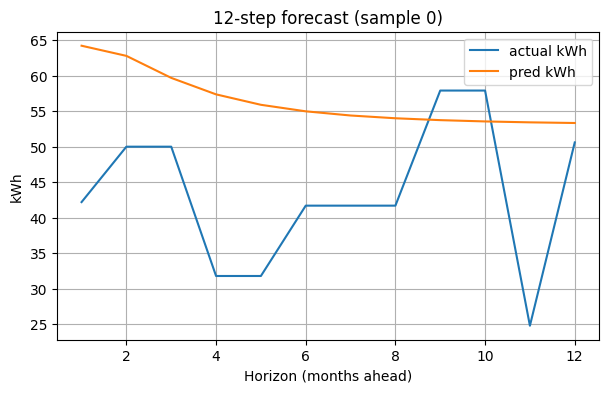

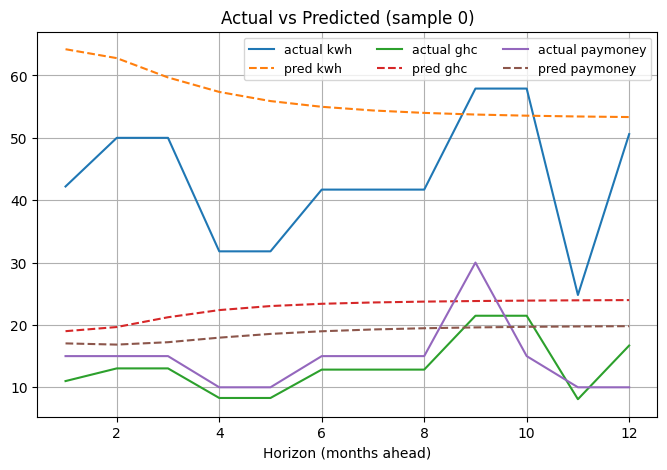

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# If you already computed these, skip the next 3 lines
yhat_va = model.predict(Xs_va, verbose=0)
yhat_va_inv = sy.inverse_transform(yhat_va.reshape(-1, yhat_va.shape[-1])).reshape(yhat_va.shape)
y_va_inv    = sy.inverse_transform(ys_va.reshape(-1, ys_va.shape[-1])).reshape(ys_va.shape)

# pick a validation example
idx = 0                      # change to inspect another sample
H   = y_va_inv.shape[1]
h   = np.arange(1, H+1)      # horizons 1..12
names = list(TARGETS)        # ["kwh","ghc","paymoney"]

# --- Plot kWh only ---
plt.figure(figsize=(7,4))
plt.plot(h, y_va_inv[idx,:,0], label="actual kWh")
plt.plot(h, yhat_va_inv[idx,:,0], label="pred kWh")
plt.xlabel("Horizon (months ahead)")
plt.ylabel("kWh")
plt.title(f"12-step forecast (sample {idx})")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot all three targets ---
plt.figure(figsize=(8,5))
for j, name in enumerate(names):
    plt.plot(h, y_va_inv[idx,:,j],        label=f"actual {name}")
    plt.plot(h, yhat_va_inv[idx,:,j], '--', label=f"pred {name}")
plt.xlabel("Horizon (months ahead)")
plt.title(f"Actual vs Predicted (sample {idx})")
plt.legend(ncol=3, fontsize=9)
plt.grid(True)
plt.show()


## 12 — Save Artifacts

In [23]:
# overwrite artifacts with BOTH scalers saved
import json, joblib

model.save(MODEL_PATH)                       # e.g., .../models/lstm_next.keras
joblib.dump((sx, sy), SCALER_PATH)           # store a tuple (X scaler, y scaler)

with open(FEATURES_PATH, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f)

print("Saved:", MODEL_PATH, SCALER_PATH, FEATURES_PATH)


Saved: ../models/lstm_next.keras ../models/scaler.pkl ../models/feature_cols.json


## 13 — Inference Utilities

In [11]:
# === Inference: streaming + pc1 alias + tuple (sx, sy) ===
import json, joblib, duckdb, numpy as np, pandas as pd
from pathlib import Path
from pandas.tseries.offsets import MonthEnd
import tensorflow as tf
from tensorflow import keras

# expects in config: DB_PATH, TABLE, MODEL_PATH, SCALER_PATH, FEATURES_PATH, SEQ_LEN, TARGETS

def _to_month_end(ts):
    ts = pd.to_datetime(ts); return ts.to_period("M").to_timestamp("M")
def _advance_month(ts, n=1):
    return _to_month_end(ts) + MonthEnd(n)

def _stream_recent_history(db_path, table, cutoff, rows_per_meter=27, batch_rows=400_000):
    sql = f"""
    WITH base AS (
      SELECT meterid, chargedate, loc, res, kwh, ghc, paymoney
      FROM {table}
      WHERE chargedate <= ?
        AND kwh >= 0 AND ghc >= 0 AND paymoney >= 0
    ),
    d AS (
      SELECT *, ROW_NUMBER() OVER (PARTITION BY meterid, chargedate ORDER BY chargedate) rn
      FROM base
    ),
    k AS (
      SELECT meterid, chargedate, loc, res, kwh, ghc, paymoney
      FROM d WHERE rn = 1
    )
    SELECT *
    FROM k
    QUALIFY ROW_NUMBER() OVER (PARTITION BY meterid ORDER BY chargedate DESC) <= ?
    ORDER BY meterid, chargedate
    """
    con = duckdb.connect(db_path)
    reader = con.execute(sql, [pd.to_datetime(cutoff), rows_per_meter]).fetch_record_batch()
    for rb in reader:  # Arrow RecordBatches
        yield rb.to_pandas()
    con.close()

def _batch_to_last_windows(df_batch, feature_cols, cutoff):
    X_list, meters = [], []
    for mid, g in df_batch.groupby("meterid", sort=False):
        g = g[g["chargedate"] <= cutoff]
        if len(g) < SEQ_LEN: 
            continue
        g = g.sort_values("chargedate").copy()

        # time
        g["month_num"] = g["chargedate"].dt.month
        g["year"]      = g["chargedate"].dt.year
        g["month_sin"] = np.sin(2*np.pi*g["month_num"]/12)
        g["month_cos"] = np.cos(2*np.pi*g["month_num"]/12)
        g["weekday"]   = g["chargedate"].dt.weekday
        g["is_weekday"] = (g["weekday"] <= 4).astype(int)
        g["is_weekend"] = 1 - g["is_weekday"]
        g["season"]     = pd.cut(g["month_num"], [0,3,6,9,12], labels=[0,1,2,3]).astype(int)

        # cats (batch codes; if you saved maps, replace here)
        g["loc_enc"] = g["loc"].astype("category").cat.codes
        g["res_enc"] = g["res"].astype("category").cat.codes

        # lags/rolling/diff/pct + pc1 alias
        for c in TARGETS:
            g[f"{c}_lag1"] = g[c].shift(1)
            g[f"{c}_lag2"] = g[c].shift(2)
            g[f"{c}_lag3"] = g[c].shift(3)
            g[f"{c}_ma3"]  = g[c].rolling(3, min_periods=3).mean()
            g[f"{c}_ma6"]  = g[c].rolling(6, min_periods=6).mean()
            g[f"{c}_ma12"] = g[c].rolling(12, min_periods=12).mean()
            g[f"{c}_diff1"] = g[c].diff(1)
            g[f"{c}_pct1"]  = g[c].pct_change(1)
            g[f"{c}_pc1"]   = g[f"{c}_pct1"]  # alias to match feature_cols

        if len(g) <= 12: 
            continue
        g = g.iloc[12:]
        if len(g) < SEQ_LEN: 
            continue

        # ensure all required columns exist
        missing = [col for col in feature_cols if col not in g.columns]
        if missing:
            raise KeyError(f"Missing features for meter {mid}: {missing}")

        X_last = g[feature_cols].to_numpy(dtype=float)[-SEQ_LEN:]
        X_list.append(X_last); meters.append(mid)

    if not X_list:
        return None, None
    return np.stack(X_list, axis=0), np.array(meters)

# custom objects (match training)
def horizon_weights(H, decay=0.15):
    w = tf.exp(-decay * tf.cast(tf.range(H), tf.float32)); return w / tf.reduce_sum(w)
_TARGET_W = {"kwh": 2.0, "ghc": 1.0, "paymoney": 1.0}
def target_weights(names): return tf.constant([_TARGET_W.get(t,1.0) for t in names], tf.float32)
def make_weighted_huber(target_names, delta=1.0, decay=0.15):
    tw = target_weights(target_names)
    def loss(y_true, y_pred):
        H = tf.shape(y_true)[1]
        hw = horizon_weights(H, decay)[tf.newaxis, :, tf.newaxis]
        err = tf.abs(y_true - y_pred)
        hub = tf.where(err < delta, 0.5*tf.square(err), delta*(err - 0.5*delta))
        return tf.reduce_sum(hub * hw * tw[tf.newaxis, tf.newaxis, :])
    loss.__name__ = "weighted_huber_ht"; return loss
def weighted_rmse(decay=0.15):
    def fn(y_true,y_pred):
        hw = horizon_weights(tf.shape(y_true)[1], decay)[tf.newaxis, :, tf.newaxis]
        return tf.sqrt(tf.reduce_sum(tf.square(y_pred-y_true)*hw))
    fn.__name__ = f"wRMSE_d{str(decay).replace('.','p')}"; return fn
def weighted_smape(decay=0.15, eps=1e-6):
    def fn(y_true,y_pred):
        hw = horizon_weights(tf.shape(y_true)[1], decay)[tf.newaxis, :, tf.newaxis]
        num = tf.abs(y_pred-y_true); den = tf.abs(y_true)+tf.abs(y_pred)+eps
        return 200.0*tf.reduce_sum((num/den)*hw)
    fn.__name__ = f"wSMAPE_d{str(decay).replace('.','p')}"; return fn
def mae_h1(y_true,y_pred): return tf.reduce_mean(tf.abs(y_true[:,0,:]-y_pred[:,0,:]))
_CUSTOM_OBJECTS = {
    "weighted_huber_ht": make_weighted_huber(TARGETS, 1.0, 0.15),
    weighted_rmse(0.15).__name__: weighted_rmse(0.15),
    weighted_smape(0.15).__name__: weighted_smape(0.15),
    "mae_h1": mae_h1,
}

def forecast_12_months(as_of: str, rows_per_meter: int = 27, batch_rows: int = 400_000) -> pd.DataFrame:
    cutoff = _to_month_end(as_of)

    feature_cols = json.loads(Path(FEATURES_PATH).read_text())
    sx, sy = joblib.load(SCALER_PATH)  # tuple (sx, sy) saved after retrain
    model = keras.models.load_model(MODEL_PATH, custom_objects=_CUSTOM_OBJECTS)

    outputs = []
    for df_batch in _stream_recent_history(DB_PATH, TABLE, cutoff, rows_per_meter, batch_rows):
        df_batch["chargedate"] = pd.to_datetime(df_batch["chargedate"])

        X_last, meter_ids = _batch_to_last_windows(df_batch, feature_cols, cutoff)
        if X_last is None: 
            continue

        Xs = sx.transform(X_last.reshape(-1, X_last.shape[2])).reshape(X_last.shape)
        preds = model.predict(Xs, batch_size=256, verbose=0)     # (M,12,3)
        M, H, T = preds.shape
        preds_inv = sy.inverse_transform(preds.reshape(-1, T)).reshape(M, H, T)

        rows = []
        for i, mid in enumerate(meter_ids):
            for h in range(1, H+1):
                rows.append([mid, _advance_month(cutoff, h), h, *preds_inv[i, h-1, :].tolist()])
        outputs.append(pd.DataFrame(rows, columns=["meterid","forecast_date","horizon","kwh","ghc","paymoney"]))

    if not outputs:
        raise ValueError("No meters had enough history to forecast.")
    out = pd.concat(outputs, ignore_index=True)
    return out.sort_values(["meterid","forecast_date"]).reset_index(drop=True)


## 14 — Final Prediction Function and Sanity Test

In [12]:
from pathlib import Path
print(Path(SCALER_PATH).with_name("scaler_y.pkl").resolve())

forecast_12_months("2020-09-30")

C:\Users\Asus\PycharmProjects\NEDCO_data_viz_app\models\scaler_y.pkl


,meterid,forecast_date,horizon,kwh,ghc,paymoney
0,2,2020-10-31,1,262.728333,163.738297,96.055412
1,2,2020-11-30,2,255.368515,159.928452,94.223595
2,2,2020-12-31,3,249.161057,159.569534,93.836876
3,2,2021-01-31,4,245.360245,159.929276,94.249664
4,2,2021-02-28,5,243.172943,160.243088,94.718895
...,...,...,...,...,...,...
577723,69062,2021-05-31,8,101.081284,66.410378,42.385612
577724,69062,2021-06-30,9,100.801941,66.494789,42.518105
577725,69062,2021-07-31,10,100.609505,66.555290,42.608166
577726,69062,2021-08-31,11,100.474686,66.599815,42.669315


# Using Validation Set for Training

In [6]:
# === Final fit on train ∪ val, then save artifacts ===
# Prereqs already defined elsewhere in your notebook:
# DB_PATH, TABLE, SEQ_LEN, TARGETS, BATCH_SIZE, BEST_EPOCH, VAL_END_DATE (or FINAL_END)
# Functions: _add_features(frame), build_training_windows(feat, SEQ_LEN, TARGETS), build_model(input_len, n_features, n_targets)
# Paths: MODEL_PATH, SCALER_PATH, FEATURES_PATH

import duckdb, pandas as pd, numpy as np, json, joblib
from pathlib import Path
import tensorflow as tf
from tensorflow import keras

# 1) Set final cutoff = end of prior validation window
FINAL_END = pd.to_datetime("2020-09-30")  # e.g., "2020-09-30"

# 2) Load data up to FINAL_END
def _load_until(end_ts):
    con = duckdb.connect(DB_PATH)
    df = con.execute(f"""
        SELECT meterid, chargedate, loc, res, kwh, ghc, paymoney
        FROM {TABLE}
        WHERE chargedate <= ?
          AND kwh >= 0 AND ghc >= 0 AND paymoney >= 0
        ORDER BY meterid, chargedate
    """, [pd.to_datetime(end_ts)]).fetchdf()
    con.close()
    df["chargedate"] = pd.to_datetime(df["chargedate"])
    # drop exact duplicates per training convention
    df = df.drop_duplicates(subset=["meterid","chargedate"])
    return df

raw = _load_until(FINAL_END)

# 3) Features and training windows (reuse your existing pipeline)
feat = add_features(raw)

C:\Users\Asus\AppData\Local\Temp\ipykernel_2476\367400307.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("meterid", group_keys=False).apply(per_meter)
C:\Users\Asus\AppData\Local\Temp\ipykernel_2476\367400307.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("meterid", group_keys=False).apply(lambda g: g.iloc[min_hist:]).reset_index(drop=True)


In [9]:
# === Final fit on train ∪ val with chunked scaling ===
from pathlib import Path
import json, numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

# 1) Feature list
feature_cols_path = Path(FEATURES_PATH)
feature_cols = None
if feature_cols_path.exists():
    feature_cols = json.loads(feature_cols_path.read_text())


# 2) Sequences (your builder)
X_all, Y_all, d_all = build_sequences_with_dates(feat, SEQ_LEN, HORIZON, feature_cols, TARGETS)

In [15]:
sx = StandardScaler().fit(X_all.reshape(-1, X_all.shape[-1]))
sy = StandardScaler().fit(Y_all.reshape(-1, Y_all.shape[-1]))

Xn = sx.transform(X_all.reshape(-1, X_all.shape[-1])).reshape(X_all.shape)
Yn = sy.transform(Y_all.reshape(-1, Y_all.shape[-1])).reshape(Y_all.shape)

In [19]:
# 4) Model (same hyperparams as tuning)
model = build_model(SEQ_LEN, Xn.shape[-1], Yn.shape[-1], HORIZON, TARGETS)

def horizon_weights(H, decay=0.15):
    w = tf.exp(-decay * tf.cast(tf.range(H), tf.float32))
    return w / tf.reduce_sum(w)
_TARGET_W = {"kwh": 2.0, "ghc": 1.0, "paymoney": 1.0}
def target_weights(names):
    return tf.constant([_TARGET_W.get(t,1.0) for t in names], dtype=tf.float32)
def make_weighted_huber(target_names, delta=1.0, decay=0.15):
    tw = target_weights(target_names)
    def loss(y_true, y_pred):
        H = tf.shape(y_true)[1]
        hw = horizon_weights(H, decay)[tf.newaxis, :, tf.newaxis]
        err = tf.abs(y_true - y_pred)
        hub = tf.where(err < delta, 0.5*tf.square(err), delta*(err - 0.5*delta))
        return tf.reduce_sum(hub * hw * tw[tf.newaxis, tf.newaxis, :])
    loss.__name__ = "weighted_huber_ht"; return loss
def weighted_rmse(decay=0.15):
    def fn(y_true, y_pred):
        H = tf.shape(y_true)[1]
        hw = horizon_weights(H, decay)[tf.newaxis, :, tf.newaxis]
        se = tf.square(y_pred - y_true)
        return tf.sqrt(tf.reduce_sum(se * hw))
    fn.__name__ = f"wRMSE_d{str(decay).replace('.','p')}"; return fn
def weighted_smape(decay=0.15, eps=1e-6):
    def fn(y_true, y_pred):
        H = tf.shape(y_true)[1]
        hw = horizon_weights(H, decay)[tf.newaxis, :, tf.newaxis]
        num = tf.abs(y_pred - y_true); den = tf.abs(y_true)+tf.abs(y_pred)+eps
        return 200.0 * tf.reduce_sum((num/den) * hw)
    fn.__name__ = f"wSMAPE_d{str(decay).replace('.','p')}"; return fn
def mae_h1(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true[:, 0, :] - y_pred[:, 0, :]))

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=make_weighted_huber(TARGETS, 1.0, 0.15),
    metrics=[weighted_rmse(0.15), weighted_smape(0.15), mae_h1],
)

# 5) Train on all data (use your best epoch count)
history = model.fit(
    Xn, Yn,
    epochs=6,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1,
)

# 6) Save artifacts
model.save(MODEL_PATH)
joblib.dump((sx, sy), SCALER_PATH)

# Save feature list if not already fixed
if feature_cols is None:
    # Persist the feature list you used to build X_all
    # If your builder uses a specific list, replace the next line with that list.
    feature_cols = json.loads(Path(FEATURES_PATH).read_text()) if Path(FEATURES_PATH).exists() else feat.select_dtypes(include=[np.number]).columns.tolist()

with open(FEATURES_PATH, "w", encoding="utf-8") as f:
    json.dump(list(feature_cols), f)

print("Saved:")
print("  MODEL_PATH   =", Path(MODEL_PATH).resolve())
print("  SCALER_PATH  =", Path(SCALER_PATH).resolve(), " (tuple (sx, sy))")
print("  FEATURES_PATH=", Path(FEATURES_PATH).resolve())
print("Shapes: X", Xn.shape, "Y", Yn.shape)


Epoch 1/6
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 402s 119ms/step - loss: 88.1654 - mae_h1: 0.2209 - w_rmse_d0p15: 14.7208 - w_smape_d0p15: 59673.1797
Epoch 2/6
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 384s 117ms/step - loss: 80.7912 - mae_h1: 0.2007 - w_rmse_d0p15: 13.8748 - w_smape_d0p15: 57487.3438
Epoch 3/6
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 392s 120ms/step - loss: 79.7016 - mae_h1: 0.1978 - w_rmse_d0p15: 13.7412 - w_smape_d0p15: 57200.7539
Epoch 4/6
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 399s 122ms/step - loss: 79.1983 - mae_h1: 0.1962 - w_rmse_d0p15: 13.6833 - w_smape_d0p15: 57001.8164
Epoch 5/6
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 408s 124ms/step - loss: 78.6856 - mae_h1: 0.1950 - w_rmse_d0p15: 13.6212 - w_smape_d0p15: 56900.4961
Epoch 6/6
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 414s 126ms/step - loss: 78.2628 - mae_h1: 0.1940 - w_rmse_d0p15: 13.5698 - w_smape_d0p15: 56790.7266
Saved:
  MODEL_PATH   = C:\Users\Asus\PycharmProjects\NEDCO_data_viz_app\models\lstm_next.keras
  SCALER_PATH  = C:\Users\Asus\PycharmProjects\NEDCO